I tried to give a single prompt to Claude to cover all aspects of the first two problems. My prompt was: 

"Please provide code to do all of this in a downloadable jupyter notebook. First, load FashionMNIST via torchvision.datasets.FashionMNIST and split the 60,000-image training set into 55,000 train / 5,000 validation samples with random_split (seeded for reproducibility). Wrap everything in DataLoaders. For preprocessing, switch to torchvision.transforms.v2, using ToImage() + ToDtype(torch.float32, scale=True). Define ImageClassifier, a small CNN (2 conv+pool blocks → FC head) for the 10 FashionMNIST classes. For training setup add an Adam optimizer, CrossEntropyLoss (xentropy), and a torchmetrics. For a training loop, I have attached a function you can use (train2). It should include the epoch loop, log a history dict (train_losses, train_metrics, valid_metrics), and validate each epoch via a companion evaluate_tm function. Next switch the evaluation, pull a validation batch, compute predictions via argmax, map predicted/actual indexes to class names, and check correctness."

I realized that "check correctness" was a bit too broad, so I added a follow up prompt: "For the correctness section, use torch.nn.functional to apply a softmax function to the predicted y values (rounded to 3 decimal points). Apply a softmax function to the top 4 y values and indexes. Calculate the total number of parameters."

The final output is below:

# FashionMNIST Image Classification

End-to-end pipeline covering:

1. **Data loading** — `FashionMNIST` via `torchvision.datasets`, split 55,000 train / 5,000 validation (seeded), wrapped in `DataLoader`s.
2. **Preprocessing** — `torchvision.transforms.v2` with `ToImage()` + `ToDtype(torch.float32, scale=True)` + normalization.
3. **Model** — `ImageClassifier`, a small CNN (2 conv+pool blocks → FC head) for the 10 FashionMNIST classes.
4. **Training setup** — Adam optimizer, `CrossEntropyLoss`, `torchmetrics.Accuracy`.
5. **Training loop** — `train2` (epoch loop + history dict) with a companion `evaluate_tm` validation function.
6. **Inference & evaluation** — `model.eval()`, predictions via `argmax`, class-name mapping, correctness check.


## 0. Setup

Install/import dependencies.

In [1]:
# If running in a fresh environment, uncomment to install dependencies:
# %pip install torch torchvision torchmetrics matplotlib


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2

import torchmetrics

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1. Preprocessing

We use `torchvision.transforms.v2`. `ToImage()` converts the input (PIL image) into a
`torch.Tensor`-backed `Image`, and `ToDtype(torch.float32, scale=True)` guarantees a
`float32` tensor with pixel values scaled to `[0, 1]` (instead of the older, deprecated
`ToTensor()`). We finish with a `Normalize` step using FashionMNIST's known
mean/std for a single grayscale channel.

In [3]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.2860], std=[0.3530]),
])


## 2. Data loading

Download FashionMNIST's train and test sets, then split the 60,000-image training set into
55,000 train / 5,000 validation samples using `random_split` with a seeded generator for
reproducibility. Wrap all three splits in `DataLoader`s.

In [4]:
SEED = 42
BATCH_SIZE = 64
DATA_DIR = "./data"

# Full training set (60,000 images) and held-out test set (10,000 images)
full_train_dataset = FashionMNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
test_dataset = FashionMNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

class_names = full_train_dataset.classes
print(f"Classes: {class_names}")
print(f"Full train size: {len(full_train_dataset)}, Test size: {len(test_dataset)}")


Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Full train size: 60000, Test size: 10000


In [5]:
# Seeded, reproducible split: 55,000 train / 5,000 validation
generator = torch.Generator().manual_seed(SEED)

train_dataset, valid_dataset = random_split(
    full_train_dataset,
    lengths=[55_000, 5_000],
    generator=generator,
)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(valid_dataset)}")


Train size: 55000
Validation size: 5000


In [6]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

# Sanity check on a single batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}, dtype: {X_batch.dtype}")
print(f"Batch y shape: {y_batch.shape}, dtype: {y_batch.dtype}")


Batch X shape: torch.Size([64, 1, 28, 28]), dtype: torch.float32
Batch y shape: torch.Size([64]), dtype: torch.int64


## 3. Model

`ImageClassifier`: a small CNN with two conv+pool blocks followed by a fully connected head,
producing logits over the 10 FashionMNIST classes.

In [7]:
class ImageClassifier(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        # Block 1: 1 x 28 x 28 -> 16 x 14 x 14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        # Block 2: 16 x 14 x 14 -> 32 x 7 x 7
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


model = ImageClassifier(num_classes=len(class_names)).to(device)
print(model)


ImageClassifier(
  (block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Training setup

Adam optimizer, cross-entropy loss, and a `torchmetrics.Accuracy` metric for multiclass
classification.

In [8]:
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
xentropy = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(
    task="multiclass", num_classes=len(class_names)
).to(device)


## 5. Training loop

`evaluate_tm` runs the model in eval mode over a data loader and returns the accumulated
metric. `train2` owns the epoch loop, logs a `history` dict (`train_losses`,
`train_metrics`, `valid_metrics`), and validates each epoch via `evaluate_tm`.

In [9]:
@torch.no_grad()
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        metric.update(y_pred, y_batch)
    return metric.compute()


In [10]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


In [11]:
N_EPOCHS = 5

history = train2(
    model=model,
    optimizer=optimizer,
    criterion=xentropy,
    metric=metric,
    train_loader=train_loader,
    valid_loader=valid_loader,
    n_epochs=N_EPOCHS,
)


MIOpen(HIP): Warning [OpenRuntimeLibraryForDevice] CK grouped conv library not found for device gfx1030: libMIOpenCKGroupedConv_gfx1030.so: cannot open shared object file: No such file or directory


Epoch 1/5, train loss: 0.4592, train metric: 0.8338, valid metric: 0.8680
Epoch 2/5, train loss: 0.3070, train metric: 0.8887, valid metric: 0.8904
Epoch 3/5, train loss: 0.2614, train metric: 0.9041, valid metric: 0.9046
Epoch 4/5, train loss: 0.2320, train metric: 0.9151, valid metric: 0.9048
Epoch 5/5, train loss: 0.2080, train metric: 0.9229, valid metric: 0.8956


### Plot training history

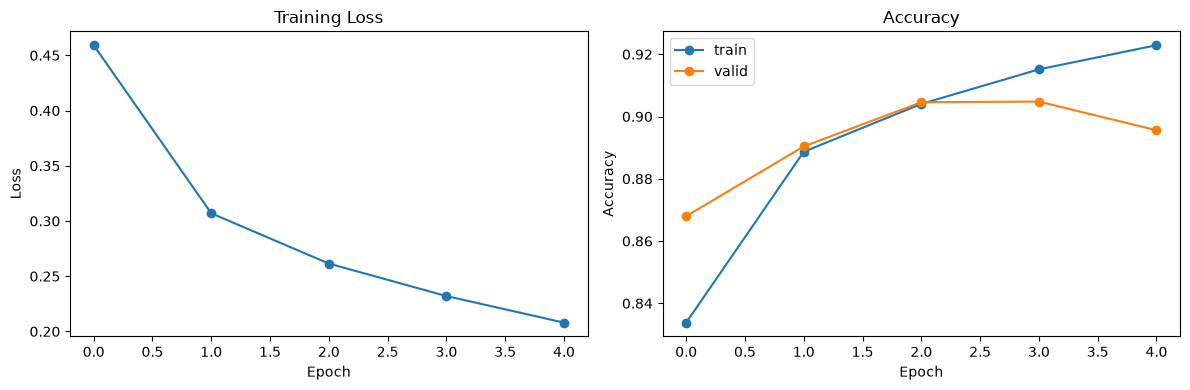

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_losses"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["train_metrics"], marker="o", label="train")
axes[1].plot(history["valid_metrics"], marker="o", label="valid")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Inference & evaluation

Switch to `model.eval()`, pull a validation batch, compute predictions via `argmax`, map
predicted/actual indices to class names, and check correctness.

In [13]:
model.eval()

X_val_batch, y_val_batch = next(iter(valid_loader))
X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)

with torch.no_grad():
    logits = model(X_val_batch)
    preds = torch.argmax(logits, dim=1)

predicted_labels = [class_names[i] for i in preds.cpu().tolist()]
actual_labels = [class_names[i] for i in y_val_batch.cpu().tolist()]
correct = [p == a for p, a in zip(predicted_labels, actual_labels)]

for i in range(len(predicted_labels)):
    status = "✓" if correct[i] else "✗"
    print(f"{status} Predicted: {predicted_labels[i]:<12} | Actual: {actual_labels[i]:<12}")

batch_accuracy = sum(correct) / len(correct)
print(f"\nBatch accuracy: {batch_accuracy:.2%}")


✓ Predicted: Sneaker      | Actual: Sneaker     
✓ Predicted: Coat         | Actual: Coat        
✓ Predicted: Pullover     | Actual: Pullover    
✓ Predicted: Sandal       | Actual: Sandal      
✓ Predicted: Ankle boot   | Actual: Ankle boot  
✓ Predicted: Bag          | Actual: Bag         
✓ Predicted: Sneaker      | Actual: Sneaker     
✗ Predicted: Sneaker      | Actual: Ankle boot  
✓ Predicted: Sneaker      | Actual: Sneaker     
✓ Predicted: Coat         | Actual: Coat        
✗ Predicted: Coat         | Actual: Dress       
✓ Predicted: Coat         | Actual: Coat        
✓ Predicted: Sneaker      | Actual: Sneaker     
✓ Predicted: Sneaker      | Actual: Sneaker     
✓ Predicted: Shirt        | Actual: Shirt       
✓ Predicted: T-shirt/top  | Actual: T-shirt/top 
✓ Predicted: Trouser      | Actual: Trouser     
✓ Predicted: Dress        | Actual: Dress       
✓ Predicted: Sneaker      | Actual: Sneaker     
✓ Predicted: Trouser      | Actual: Trouser     
✓ Predicted: Coat   

### Visualize a few predictions

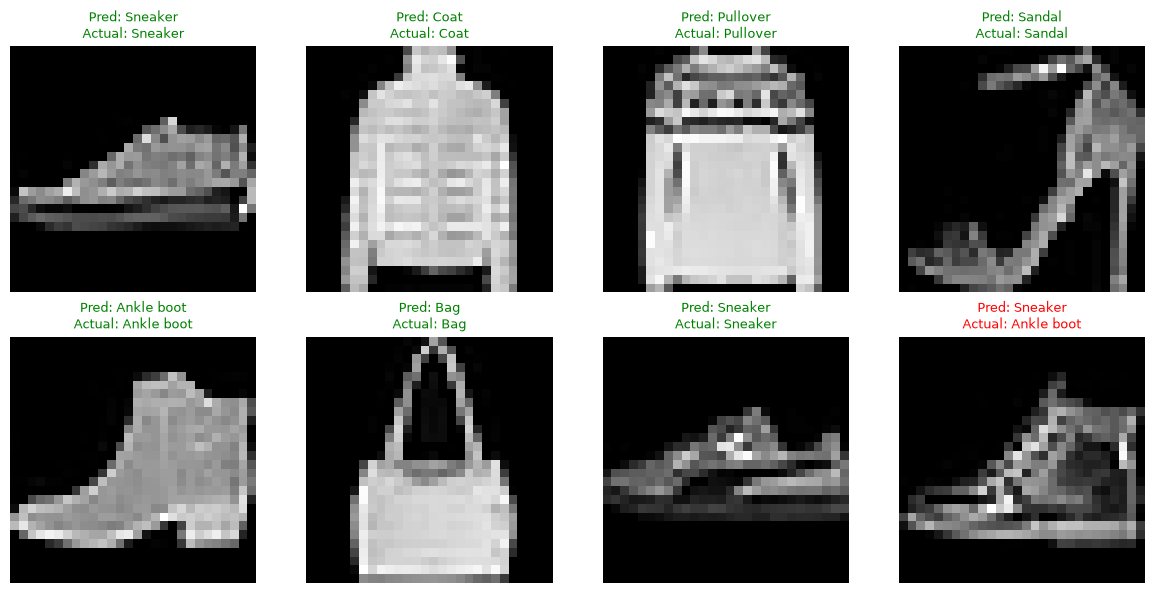

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Undo normalization for display purposes
mean, std = 0.2860, 0.3530

for idx, ax in enumerate(axes.flat):
    img = X_val_batch[idx].cpu().squeeze(0) * std + mean
    ax.imshow(img, cmap="gray")
    title_color = "green" if correct[idx] else "red"
    ax.set_title(
        f"Pred: {predicted_labels[idx]}\nActual: {actual_labels[idx]}",
        color=title_color, fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Final evaluation on the held-out test set

In [15]:
test_accuracy = evaluate_tm(model, test_loader, metric)
print(f"Test accuracy: {test_accuracy.item():.4f}")

import torch.nn.functional as F

# Get raw logits for the validation batch
model.eval()
with torch.no_grad():
    eval_outputs = model(X_val_batch)

# Convert logits to class probabilities
probabilities = F.softmax(eval_outputs, dim=1)
probabilities.round(decimals=3)

# Top-4 predicted classes and their softmax probabilities
top4_probs, top4_indexes = torch.topk(probabilities, k=4, dim=1)
top4_probs = torch.round(top4_probs * 1000) / 1000

print("Top-4 probabilities:\n", top4_probs)
print("Top-4 indexes:\n", top4_indexes)

# Optional: map top-4 indexes to class names for readability
top4_classes = [[class_names[i] for i in row] for row in top4_indexes.cpu().tolist()]
print("Top-4 classes:\n", top4_classes)

# Total number of parameters in the model
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


Test accuracy: 0.8923
Top-4 probabilities:
 tensor([[0.9990, 0.0010, 0.0000, 0.0000],
        [0.9950, 0.0040, 0.0010, 0.0000],
        [0.5340, 0.3510, 0.0690, 0.0400],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.9780, 0.0220, 0.0000, 0.0000],
        [0.9980, 0.0020, 0.0000, 0.0000],
        [0.7440, 0.2380, 0.0130, 0.0020],
        [0.8030, 0.1820, 0.0140, 0.0000],
        [0.9840, 0.0150, 0.0010, 0.0000],
        [0.9990, 0.0010, 0.0000, 0.0000],
        [0.9960, 0.0020, 0.0010, 0.0010],
        [0.9290, 0.0640, 0.0040, 0.0010],
        [0.9960, 0.0040, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.9960, 0.0030, 0.0010, 0.0000],
        [0.9930, 0.0070, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.7270, 0.2570, 0.0160, 0.0000],
        [0.9890, 0.0070, 0.0040, 0.0000],
        [0.5920, 0.3140, 0.0830,